|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

### Problème 2B7

<img src='../images/Chap-2-Prob-2B7.png'>

In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# définitions variables, paramètres.
r,L,mu,R,rho,g,kappa,v_0=sp.symbols('r,L,mu,R,rho,g,kappa,v_0')
v_z=sp.Function('v_z')(r)
tau_rz=sp.Function('tau_rz')(r)

In [3]:
eq1=r*tau_rz
eq2=-1/r*eq1.diff(r)
display(eq2)

In [4]:
eq3=sp.dsolve(eq2)
display(eq3)               

In [5]:
eq4=eq3.subs(tau_rz,-mu*v_z.diff(r))     # substituer la loi de Newton pour le taux
display(eq4)

In [6]:
v_z=sp.dsolve(eq4)
display('profil de vitesse général, avant de trouver les constantes C1 et C2',v_z)

'profil de vitesse général, avant de trouver les constantes C1 et C2'

'conditions aux limites'

'constantes C1 et C2'

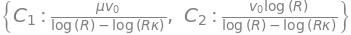

In [7]:
v_z=v_z.rhs
condition_1=sp.Eq(v_z.subs(r,R),0)
condition_2=sp.Eq(v_z.subs(r,kappa*R)-v_0,0)
display('conditions aux limites',condition_1,condition_2)
constantes=sp.solve([condition_1,condition_2], sp.symbols('C1,C2'))
display('constantes C1 et C2',constantes)

'profil de vitesse après substitution des constantes C1 et C2'

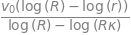

In [8]:
v_z=v_z.subs(constantes)
display('profil de vitesse après substitution des constantes C1 et C2',v_z.simplify())

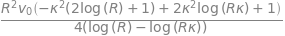

In [9]:
#
# Débit volumétrique
#
debit=sp.integrate(v_z*r,(r,kappa*R,R))
display(debit.simplify())

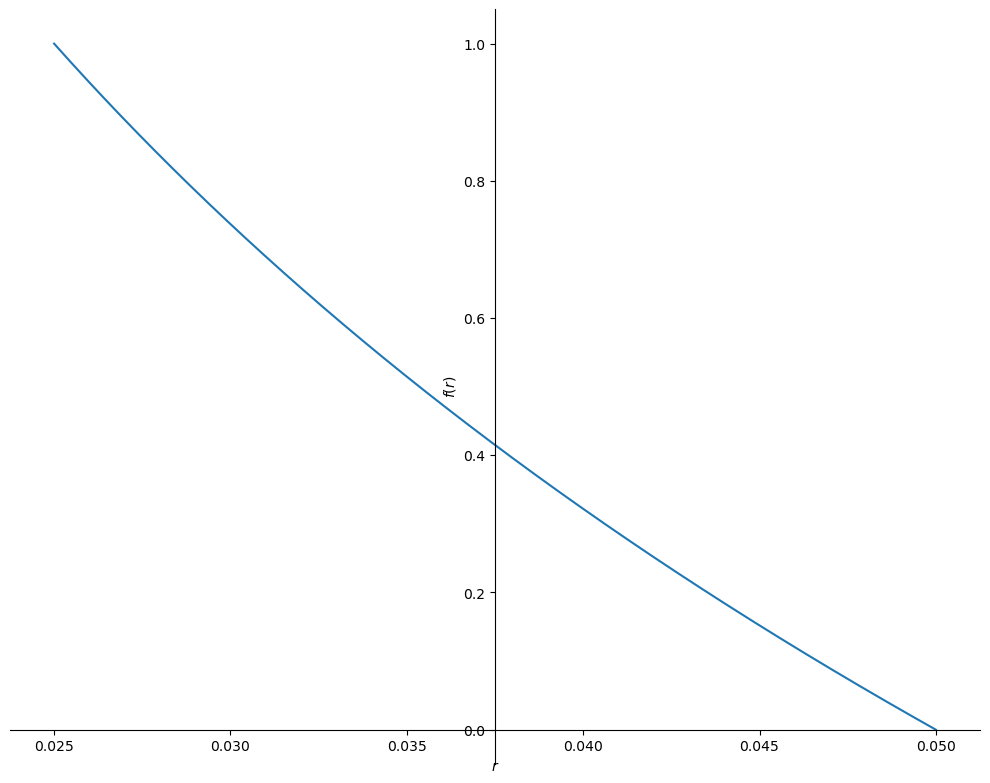

In [10]:
dictionnaire={'mu':0.001,'R':0.05,'kappa':0.5,'v_0':1}
display(debit.subs(dictionnaire))
v_z=v_z.subs(dictionnaire)
kappa=kappa.subs(dictionnaire)
R=R.subs(dictionnaire)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10,8  
sp.plot(v_z,(r,kappa*R,R));